Titanic Dataset EDA

In [62]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


LOADING DATASET

In [77]:
df = pd.read_csv("titanic.csv")

Understanding Data

In [ ]:
df.head()
df.tail()
df.shape
df.info()
df.describe()

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
886,0,2,male,27.000000,0,0,13.00,Second,man,True,Southampton,no,True
887,1,1,female,19.000000,0,0,30.00,First,woman,False,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.45,Third,woman,False,Southampton,no,False
889,1,1,male,26.000000,0,0,30.00,First,man,True,Cherbourg,yes,True
890,0,3,male,32.000000,0,0,7.75,Third,man,True,Queenstown,no,True


Cleaning Data

In [65]:
#Checking Null or NAN values in Columns
df.isna().sum()
df
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Filling and Removing Null/NAN values (Where Needed)

In [78]:
df['age'].fillna(df['age'].mean() , inplace=True)
df.drop(['deck'] , axis=1 ,inplace=True)
df.drop(['embarked'], axis=1, inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0] , inplace=True)


Identifying and Removing Outliers

In [112]:
#Removing Outliers

df = df[df['age']<58]
df.shape


(858, 13)

Log Transformation for minimizing impact of Outliers

In [ ]:
df['fare']=np.log(df['fare'])

BOX PLOT

<Axes: xlabel='fare'>

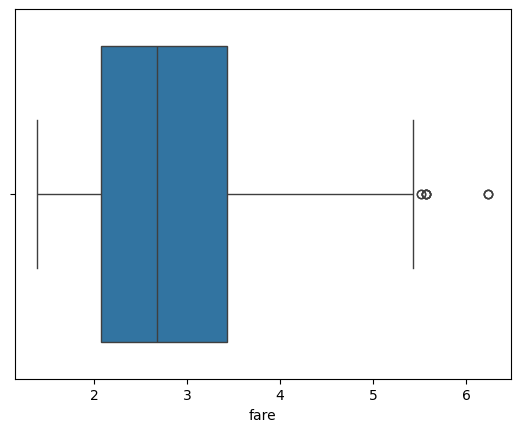

In [123]:
sns.boxplot(x=df['fare'] )

Scatter plot

<function matplotlib.pyplot.show(close=None, block=None)>

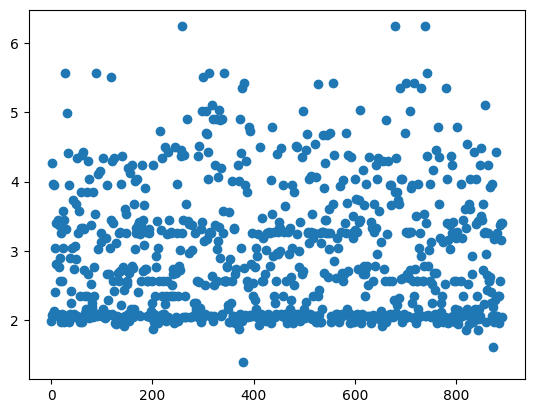

In [120]:
plt.scatter(df.index,df['fare'])
plt.show

Survival Rate Through Class and Gender

In [88]:
df.groupby(['sex', 'class'])['survived'].mean()

sex     class 
female  First     0.968085
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64

RELATIONSHIP

<Axes: >

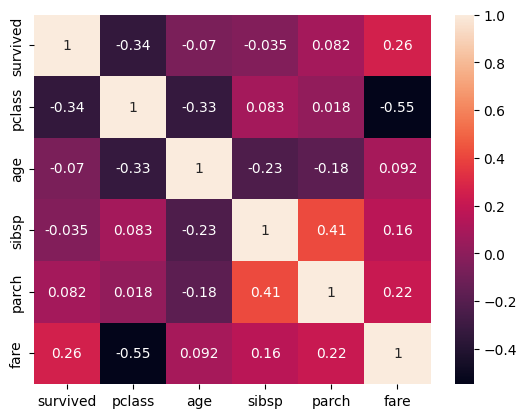

In [100]:
 df_num = df.select_dtypes(include=['int64','float64'])

 df_corr = df_num.corr()
 sns.heatmap(df_corr , annot=True)

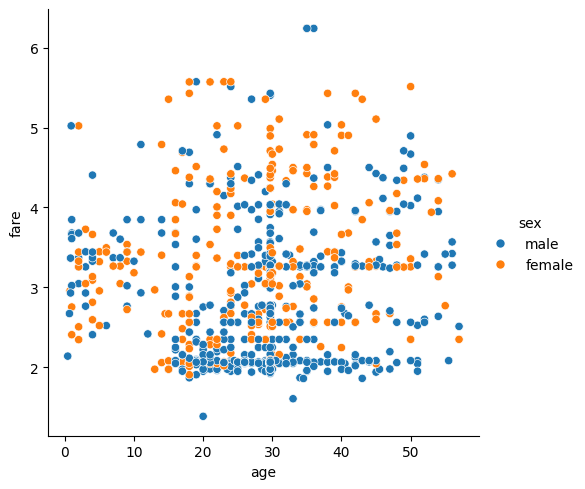

In [127]:
sns.relplot(x='age', y='fare', hue='sex', data=df) 